# Medical Cost Personal Datasets

**Data**: [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)

# 📊 Машиналық оқыту: Регрессия түрлері және Масштабтау

Бұл блокнот **Medical Cost Personal Datasets** (Медициналық сақтандыру шығындарын болжау) тапсырмасына арналған теориялық негіздерді қамтиды. Мақсатымыз – пациенттің жасы, салмағы, шылым шегуі сияқты белгілеріне (features) қарап, оның сақтандыру шығынын (target) болжау.

---

## 1. Қарапайым Сызықтық Регрессия (Linear Regression)

Сызықтық регрессия айнымалылар арасындағы байланысты **түзу сызық** ретінде сипаттайды. Ол "белгілер өскен сайын, нәтиже де бірқалыпты өседі (немесе кемиді)" деген болжамға сүйенеді.



**Математикалық формуласы:**
$$y=\beta_0+\beta_1x_1+\beta_2x_2+\dots+\beta_nx_n$$

* $y$ — біз болжағымыз келетін мән (сақтандыру шығыны).
* $x_1, x_2, \dots, x_n$ — тәуелсіз айнымалылар немесе белгілер (жасы, BMI, бала саны).
* $\beta_0$ — еркін мүше (түзудің y-осін қиып өтетін нүктесі).
* $\beta_1, \beta_2, \dots, \beta_n$ — әр белгінің салмағын (маңыздылығын) көрсететін коэффициенттер.

---

## 2. Полиномиалды Регрессия (Polynomial Regression)

Егер деректердегі байланыс түзу сызықты емес, күрделірек (қисық сызықты) болса, сызықтық регрессия нашар жұмыс істейді. Бұл жағдайда біз бастапқы белгілердің дәрежелерін (квадрат, куб) қосамыз.



**Математикалық формуласы (бір айнымалы үшін 2-ші дәрежелі полином):**
$$y=\beta_0+\beta_1x+\beta_2x^2+\epsilon$$

Бұл модельдің артықшылығы – ол `BMI` немесе `Жас` көрсеткіштерінің белгілі бір шектен асқанда шығындарды күрт өсіретінін (экспоненциалды өсу) тани алады.

---
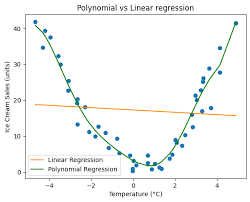
---

## 3. Ridge Регрессиясы (L2 Regularization)

Полиномиалды белгілерді көп қосқанда, модель деректерді тым қатты "жаттап" алып, жаңа деректерге келгенде қателесетін болады (бұны **Overfitting** дейміз). Ridge регрессиясы модельдегі коэффициенттердің ($\beta$) шектен тыс үлкен болып кетуіне "айыппұл" (penalty) салады.



**Қателікті есептеу (Loss Function) формуласы:**
$$L(\beta)=\sum_{i=1}^{m}(y_i-\hat{y}_i)^2+\alpha\sum_{j=1}^{n}\beta_j^2$$

* $\sum_{i=1}^{m}(y_i-\hat{y}_i)^2$ — бұл қарапайым қателік (шынайы мән мен болжамның айырмашылығы).
* $\alpha$ — регуляризация күші (айыппұлдың қаншалықты қатаң болатынын шешеді).
* $\sum_{j=1}^{n}\beta_j^2$ — L2 айыппұлы (коэффициенттердің квадраттарының қосындысы). Бұл бөлік коэффициенттерді нөлге жақындатады, бірақ толық нөл қылмайды.

---
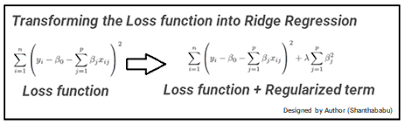
---

## 4. Деректерді Масштабтау (StandardScaler)

Ridge регрессиясын қолданбас бұрын **міндетті түрде** барлық сандық белгілерді бір масштабқа келтіру қажет. Әйтпесе, үлкен сандары бар бағандар (мысалы, BMI) кіші сандары бар бағандарға (мысалы, бала саны) қарағанда айыппұлды көбірек алып қояды.



**Стандарттау формуласы:**
$$z=\frac{x-\mu}{\sigma}$$

* $x$ — бастапқы мән.
* $\mu$ — бағанның орташа мәні.
* $\sigma$ — стандартты ауытқу (деректердің шашыраңқылығы).
* $z$ — масштабталған жаңа мән (орташа мәні 0, ауытқуы 1 болады).

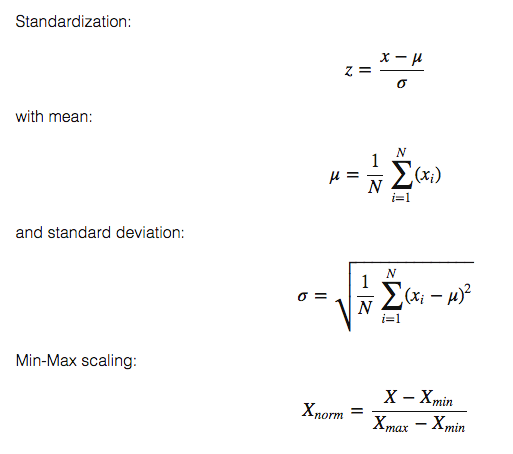

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
path = "/content/insurance.csv"
df = pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape   # Датасет өлшемі

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df['region'] = label_encoder.fit_transform(df['region'])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# 📘 LabelEncoder — fit / transform / fit_transform шпаргалка

## 🔹 LabelEncoder деген не?
Категориялық мәндерді санға айналдырады.

Мысал:
```
["cat", "dog", "bird"]
→ [1, 2, 0]
```

---

# ⚙️ 1) fit()

### Не істейді?
- Берілген деректен **бірегей категорияларды үйренеді**
- Ішкі mapping жасайды
- Бірақ деректі өзгертпейді

### Код:
```python
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['animal'])
```

### Ішкі mapping мысалы:
```
bird → 0
cat  → 1
dog  → 2
```

---

# ⚙️ 2) transform()

### Не істейді?
- Алдын ала үйренген mapping бойынша мәндерді санға айналдырады

### Код:
```python
le.transform(df['animal'])
```

### Нәтиже:
```
["cat", "dog"] → [1, 2]
```

⚠ Егер жаңа категория келсе → ҚАТЕ шығады.

---

# ⚙️ 3) fit_transform()

### Не істейді?
- Алдымен fit()
- Сосын transform()

### Код:
```python
le.fit_transform(df['animal'])
```

---

# 📊 Айырмашылық

| Метод | Не істейді | Қашан қолдану |
|-------|------------|---------------|
| fit() | Mapping үйрену | Train кезінде |
| transform() | Кодтау | Test кезінде |
| fit_transform() | Екеуі бірге | Train үшін ыңғайлы |

---

# 🎯 ML ережесі (Маңызды!)

Train set:
```
fit + transform
```

Test set:
```
тек transform
```

Неге?
Егер test-ке fit жасасаң → Data Leakage болады.

---

# 🧠 Есте сақтау формуласы

```
fit()           = ҮЙРЕНУ
transform()     = ҚОЛДАНУ
fit_transform() = ҮЙРЕНУ + ҚОЛДАНУ
```


In [11]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


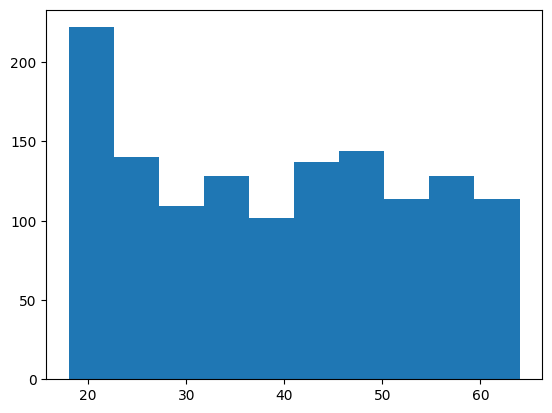

In [21]:
plt.hist(df['age'], bins=10)
plt.show()

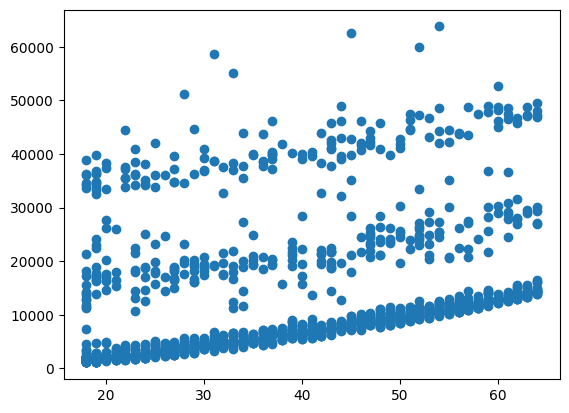

In [23]:
plt.scatter(df['age'], df['charges'])
plt.show()

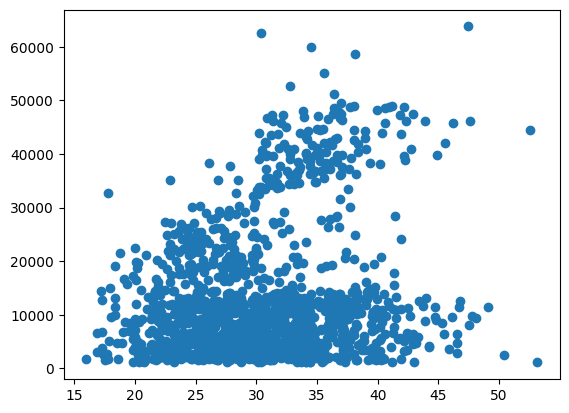

In [25]:
plt.scatter(df['bmi'], df['charges'])
plt.show()

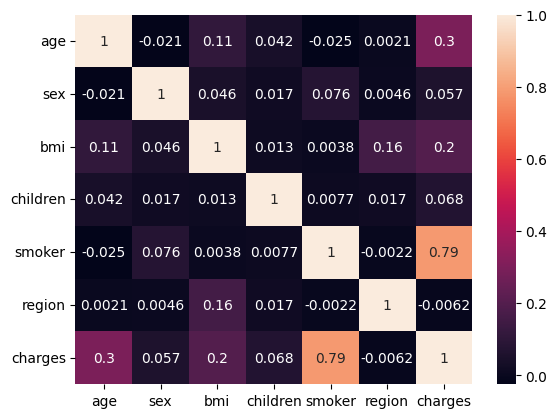

In [20]:
sns.heatmap(df.corr(), annot=True)
plt.show()

## Linear Regression

In [14]:
X = df.drop('charges', axis=1)
y = df['charges']
X, y

(      age  sex     bmi  children  smoker  region
 0      19    0  27.900         0       1       3
 1      18    1  33.770         1       0       2
 2      28    1  33.000         3       0       2
 3      33    1  22.705         0       0       1
 4      32    1  28.880         0       0       1
 ...   ...  ...     ...       ...     ...     ...
 1333   50    1  30.970         3       0       1
 1334   18    0  31.920         0       0       0
 1335   18    0  36.850         0       0       2
 1336   21    0  25.800         0       0       3
 1337   61    0  29.070         0       1       1
 
 [1338 rows x 6 columns],
 0       16884.92400
 1        1725.55230
 2        4449.46200
 3       21984.47061
 4        3866.85520
            ...     
 1333    10600.54830
 1334     2205.98080
 1335     1629.83350
 1336     2007.94500
 1337    29141.36030
 Name: charges, Length: 1338, dtype: float64)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [26]:
# Сызықтық регрессия
lin_model = LinearRegression()

# Модельді оқыту
lin_model.fit(X_train, y_train)
lin_model.coef_, lin_model.intercept_

(array([  259.870936  ,    48.14518497,   337.05864381,   427.52339986,
        23622.50371905,  -299.04523816]),
 np.float64(-12117.149214175606))

In [33]:
# Болжам жасау
lin_pred = lin_model.predict(X_test)

# Орташа квадраттық ауытқу
mse = mean_squared_error(y_test, lin_pred)

# Орташа абсолют ауытқу
mae = mean_absolute_error(y_test, lin_pred)

# R2-score
r2 = r2_score(y_test, lin_pred)

print(f"MSE: {mse}\nMAE: {mae}\nR2: {r2}")

MSE: 35174149.327053055
MAE: 4252.8564557923655
R2: 0.7668905583460909


# 📏 Регрессия Метрикалары: MAE, MSE (RMSE) және R²

Машиналық оқытуда регрессия моделін құрғаннан кейін, оның қаншалықты қателесіп жатқанын сандармен өлшеу керек. Төменде ең негізгі 3 метриканың айырмашылығы мен формулалары келтірілген.



---

## 1. MAE (Mean Absolute Error - Орташа абсолютті қателік)

**Бұл не?** Түсінуге ең оңай метрика. Ол модельдің әр болжамы шынайы мәннен **орта есеппен қаншаға (қанша долларға) қателескенін** көрсетеді. Мұнда қателіктің бағыты маңызды емес (көп айтты ма, аз айтты ма), тек оның модулі (абсолютті мәні) алынады.

**Формуласы:**
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

* $n$ — жалпы нүктелер (пациенттер) саны.
* $y_i$ — нақты (шынайы) мән.
* $\hat{y}_i$ — модельдің болжаған мәні.

**Қашан қолданамыз?** Бізге қателікті қарапайым адам түсінетін тілде, бастапқы өлшем бірлігімен (мысалы, доллар) түсіндіру керек болғанда.

---

## 2. MSE және RMSE (Орташа квадраттық қателік)

**Бұл не?** MSE қателіктерді жай ғана қоспайды, оларды **квадраттайды**. Бұл не үшін керек? Егер модель бір адамның шығынын болжауда өте қатты қателессе (мысалы, $20,000-ға), квадраттау арқылы бұл қателік одан сайын үлкейіп, модельге **"үлкен айыппұл"** салынады.
Ал сіз айтып отырған **std** (стандартты ауытқу) немесе **RMSE** — сол MSE-ден алынған түбір. Квадратталған долларды қайтадан қалыпты долларға айналдыру үшін түбір аламыз.

**Формулалары:**
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
$$RMSE = \sqrt{MSE}$$

**Қашан қолданамыз?** Біз үшін кішкентай қателіктер кешірімді, бірақ **үлкен қателіктерді (outliers) жібермеу өте маңызды** болған кезде қолданылады.

---

## 3. R² (R-squared - Детерминация коэффициенті)

**Бұл не?** MAE мен MSE қателікті доллармен өлшесе, R² модельдің **сапасын пайызбен (0-ден 1-ге дейін)** көрсетеді. Ол "біздің модель жай ғана орташа мәнді ала салған ең қарапайым (ақымақ) модельге қарағанда қаншалықты жақсы?" деген сұраққа жауап береді.

**Формуласы:**
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

* $\bar{y}$ — барлық шынайы мәндердің орташа арифметикалық көрсеткіші.

**Қалай түсінеміз?**
* **$R^2 = 1$ (100%)** — Модель мінсіз, ешқандай қателік жоқ.
* **$R^2 = 0.76$ (76%)** — Модель сақтандыру шығынындағы өзгерістердің 76%-ын дұрыс танып, түсіндіре алды. Жақсы көрсеткіш!
* **$R^2 = 0$** — Модель мүлдем жұмыс істемейді, ол жай ғана барлығына орташа санды болжай салып жатыр.

---

### 💡 Қысқаша түйін (Айырмашылығы неде?)

| Метрика | Нені білдіреді? | Өлшем бірлігі | Үлкен қателіктерге сезімталдығы |
| :--- | :--- | :--- | :--- |
| **MAE** | Орташа есеппен қаншаға қателестік? | Бастапқы (мысалы, $) | Төмен (бәріне тең қарайды) |
| **MSE / RMSE** | Қателіктердің шашыраңқылығы қандай? | Квадратталған ($²) / Бастапқы ($) | **Жоғары** (үлкен қателіктерге мән береді) |
| **R²** | Модельдің жалпы дәлдігі қандай? | Пайыз (0 - 1 аралығында) | - |

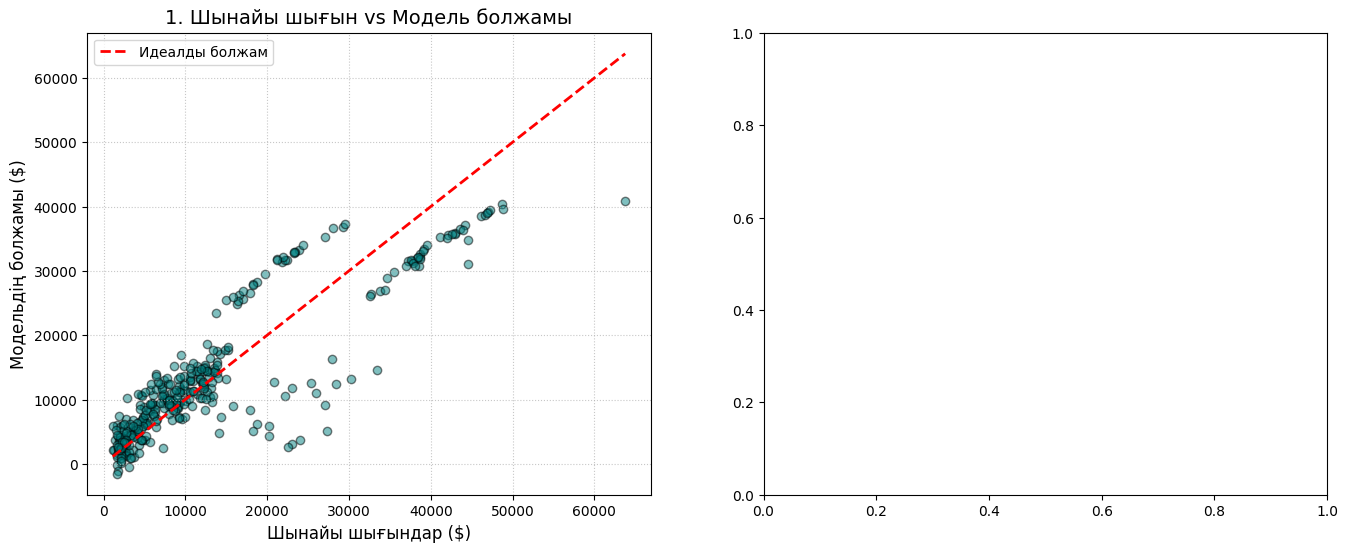

In [32]:
# Модельдің болжамдарын алу (егер алмаған болсаңыз)
# y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# 1-ГРАФИК: Шынайы мән мен Болжам (Actual vs Predicted)
# ---------------------------------------------------------
axes[0].scatter(y_test, lin_pred, alpha=0.5, color='teal', edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linestyle='--', lw=2, label='Идеалды болжам')
axes[0].set_title('1. Шынайы шығын vs Модель болжамы', fontsize=14)
axes[0].set_xlabel('Шынайы шығындар ($)', fontsize=12)
axes[0].set_ylabel('Модельдің болжамы ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

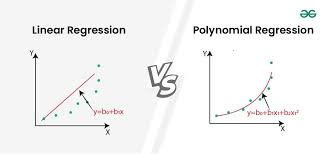

In [39]:
# 1. Pipeline (Құбыржол) құру
# Ол барлық қадамдарды ретімен, қатесіз орындайды
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # 1-қадам: Жаңа бағандар (квадраттар мен көбейтінділер) жасау
    ('scaler', StandardScaler()),                               # 2-қадам: Барлығын бір масштабқа келтіру
    ('ridge', Ridge(alpha=1.0))                                 # 3-қадам: Ridge регрессиясы арқылы оқыту
])

# 2. Модельді оқыту
poly_model.fit(X_train, y_train)

# 3. Болжам жасау
y_pred_poly = poly_model.predict(X_test)

# 4. Жаңа нәтижелерді көру
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

In [40]:
print("🚀 СЫЗЫҚТЫҚ РЕГРЕССИЯ МОДЕЛЬДІҢ НӘТИЖЕЛЕРІ:")
print("-" * 40)
print(f"Жаңа R² Score (Дәлдік):       {r2:.4f} (немесе {r2*100:.1f}%)")
print(f"Жаңа MAE (Орташа қателік):   ${mae:.2f}")
print("-" * 40)

print("🚀 ПОЛИНОМИАЛДЫ МОДЕЛЬДІҢ НӘТИЖЕЛЕРІ:")
print("-" * 40)
print(f"Жаңа R² Score (Дәлдік):       {r2_poly:.4f} (немесе {r2_poly*100:.1f}%)")
print(f"Жаңа MAE (Орташа қателік):   ${mae_poly:.2f}")
print("-" * 40)

🚀 СЫЗЫҚТЫҚ РЕГРЕССИЯ МОДЕЛЬДІҢ НӘТИЖЕЛЕРІ:
----------------------------------------
Жаңа R² Score (Дәлдік):       0.7669 (немесе 76.7%)
Жаңа MAE (Орташа қателік):   $4252.86
----------------------------------------
🚀 ПОЛИНОМИАЛДЫ МОДЕЛЬДІҢ НӘТИЖЕЛЕРІ:
----------------------------------------
Жаңа R² Score (Дәлдік):       0.8563 (немесе 85.6%)
Жаңа MAE (Орташа қателік):   $2786.53
----------------------------------------


# 🚀 Модель нәтижелерін салыстыру: Linear vs. Polynomial

Бұл бөлімде біз қарапайым **Сызықтық регрессия** мен **Полиномиалды Ridge регрессиясының** нәтижелерін салыстырамыз. Модельдің күрделілігін арттыру арқылы болжам дәлдігінің қалай өзгергенін көре аламыз.

---

### 📈 Нәтижелер кестесі

| Метрика | Сызықтық регрессия (Linear) | Полиномиалды регрессия (Poly + Ridge) | Жақсарту (Improvement) |
|:---|:---:|:---:|:---:|
| **R² Score (Дәлдік)** | 76.7% | **85.6%** | **+8.9%** |
| **MAE (Орташа қателік)** | $4,252.86$ | **$2,786.53$** | **-$1,466.33$** |

---

### 🔍 Неге Полиномиалды модель жақсырақ жұмыс істеді?

Сызықтық модель барлық белгілерді бір-біріне тәуелсіз және түзу сызық бойымен өседі деп есептеді. Алайда, **Полиномиалды модель** (2-ші дәрежелі) мынадай маңызды факторларды таба алды:

1.  **Interaction Terms (Өзара әрекеттесу):** Модель $BMI \times Smoker$ сияқты жаңа байланыстарды жасады. Шынайы өмірде шылым шегетін және салмағы жоғары адамдардың шығыны жай ғана қосынды емес, экспоненциалды түрде өседі.
2.  **Non-linear Relationships (Сызықтық емес байланыс):** Жас ұлғайған сайын денсаулыққа жұмсалатын шығын бірқалыпты емес, белгілі бір жастан кейін (мысалы, 50-ден асқанда) күрт артатынын $Age^2$ арқылы түсінді.



---

### 🛠️ Қолданылған технологиялық тізбек (Pipeline)

Модельдің дәлдігін арттыру үшін мынадай қадамдар жасалды:
1.  **PolynomialFeatures (degree=2):** Белгілердің квадраты мен көбейтінділері қосылды.
2.  **StandardScaler:** Барлық жаңадан пайда болған үлкен сандар бір масштабқа (орташа мәні 0, ауытқуы 1) келтірілді.
3.  **Ridge Regression:** Модель тым күрделі болып, деректерді жаттап алмас үшін (overfitting) L2 регуляризациясы қолданылды.

---
**Қорытынды:** Полиномиалды модельді қолдану арқылы біз қателікті **$1,466-ға** азайттық. Бұл сақтандыру шығындарын болжау үшін айтарлықтай үлкен жеңіс.

In [43]:
import joblib

# 'poly_model' — біздің Pipeline-ның атауы
# 'insurance_model_v1.pkl' — файлдың атауы (кез келген атау беруге болады)
joblib.dump(poly_model, 'insurance_poly_ridge_model_v1.pkl')
joblib.dump(lin_model, 'insurance_linear_model_v1.pkl')

print("✅ Модель сәтті сақталды!")

✅ Модель сәтті сақталды!
